In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from sklearn.cross_decomposition import PLSRegression

In [ ]:
df=pd.read_csv('/content/nba_final.csv')

In [ ]:
df

,Rk,Player.x,Player_ID,Pos1,Pos2,Age,Tm,G,GS,MP,...,Conference,Role,Fvot,FRank,Pvot,PRank,Mvot,MRank,Score,Play
0,170,A.J. Hammons,hammoaj01,C,NaN,24,DAL,22,0,7.4,...,West,Front,786,123,NaN,NaN,NaN,NaN,83.5,No
1,58,Aaron Brooks,brookaa01,PG,NaN,32,IND,65,0,13.8,...,Est,Back,2474,64,NaN,NaN,NaN,NaN,48.2,No
2,157,Aaron Gordon,gordoaa01,SF,NaN,21,ORL,80,72,28.7,...,Est,Front,22774,29,NaN,NaN,NaN,NaN,40.0,No
3,352,Adreian Payne,paynead01,PF,NaN,25,MIN,18,0,7.5,...,West,Front,861,120,1.0,52.0,NaN,NaN,75.5,No
4,10,Al-Farouq Aminu,aminual01,PF,NaN,26,POR,61,25,29.1,...,West,Front,4971,69,7.0,23.0,NaN,NaN,42.8,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,109,Zach Collins,colliza01,C,NaN,21,POR,77,0,17.6,...,West,Front,16287,74,1.0,52.0,0.0,8.0,86.8,No
1404,294,Zach LaVine,lavinza01,SG,NaN,23,CHI,63,62,34.5,...,Est,Back,519746,7,17.0,8.0,0.0,8.0,36.5,No
1405,308,Zach Lofton,loftoza01,SG,NaN,26,DET,1,0,4.0,...,Est,Back,136,114,0.0,61.0,0.0,8.0,132.2,No
1406,393,Zaza Pachulia,pachuza01,C,NaN,34,DET,68,3,12.9,...,Est,Front,21525,50,2.0,41.0,0.0,7.0,69.8,No


In [ ]:
df.shape

(1408, 45)

In [ ]:
df.head()

,Rk,Player.x,Player_ID,Pos1,Pos2,Age,Tm,G,GS,MP,...,Conference,Role,Fvot,FRank,Pvot,PRank,Mvot,MRank,Score,Play
0,170,A.J. Hammons,hammoaj01,C,NaN,24,DAL,22,0,7.4,...,West,Front,786,123,NaN,NaN,NaN,NaN,83.5,No
1,58,Aaron Brooks,brookaa01,PG,NaN,32,IND,65,0,13.8,...,Est,Back,2474,64,NaN,NaN,NaN,NaN,48.2,No
2,157,Aaron Gordon,gordoaa01,SF,NaN,21,ORL,80,72,28.7,...,Est,Front,22774,29,NaN,NaN,NaN,NaN,40.0,No
3,352,Adreian Payne,paynead01,PF,NaN,25,MIN,18,0,7.5,...,West,Front,861,120,1.0,52.0,NaN,NaN,75.5,No
4,10,Al-Farouq Aminu,aminual01,PF,NaN,26,POR,61,25,29.1,...,West,Front,4971,69,7.0,23.0,NaN,NaN,42.8,No


In [ ]:
df.dtypes

,0
Rk,int64
Player.x,object
Player_ID,object
Pos1,object
Pos2,object
Age,int64
Tm,object
G,int64
GS,int64
MP,float64


In [ ]:
df.isnull().sum(axis=0) #calculate the no of null values column wise

,0
Rk,0
Player.x,0
Player_ID,0
Pos1,0
Pos2,1396
Age,0
Tm,0
G,0
GS,0
MP,0


In [ ]:
df.isnull().sum(axis=1)   #calculate the number of null values row wise

,0
0,6
1,5
2,5
3,3
4,3
...,...
1403,1
1404,1
1405,4
1406,1


In [ ]:
df.drop(columns ='Pos2',inplace= True)

In [ ]:
df

,Rk,Player.x,Player_ID,Pos1,Age,Tm,G,GS,MP,FG,...,Conference,Role,Fvot,FRank,Pvot,PRank,Mvot,MRank,Score,Play
0,170,A.J. Hammons,hammoaj01,C,24,DAL,22,0,7.4,0.8,...,West,Front,786,123,NaN,NaN,NaN,NaN,83.5,No
1,58,Aaron Brooks,brookaa01,PG,32,IND,65,0,13.8,1.9,...,Est,Back,2474,64,NaN,NaN,NaN,NaN,48.2,No
2,157,Aaron Gordon,gordoaa01,SF,21,ORL,80,72,28.7,4.9,...,Est,Front,22774,29,NaN,NaN,NaN,NaN,40.0,No
3,352,Adreian Payne,paynead01,PF,25,MIN,18,0,7.5,1.3,...,West,Front,861,120,1.0,52.0,NaN,NaN,75.5,No
4,10,Al-Farouq Aminu,aminual01,PF,26,POR,61,25,29.1,3.0,...,West,Front,4971,69,7.0,23.0,NaN,NaN,42.8,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,109,Zach Collins,colliza01,C,21,POR,77,0,17.6,2.5,...,West,Front,16287,74,1.0,52.0,0.0,8.0,86.8,No
1404,294,Zach LaVine,lavinza01,SG,23,CHI,63,62,34.5,8.4,...,Est,Back,519746,7,17.0,8.0,0.0,8.0,36.5,No
1405,308,Zach Lofton,loftoza01,SG,26,DET,1,0,4.0,0.0,...,Est,Back,136,114,0.0,61.0,0.0,8.0,132.2,No
1406,393,Zaza Pachulia,pachuza01,C,34,DET,68,3,12.9,1.3,...,Est,Front,21525,50,2.0,41.0,0.0,7.0,69.8,No


In [ ]:
df=df.fillna(0)

In [ ]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#deleting useless columns
df.drop(columns=['Player.x','Player_ID'],inplace=True)


## **Encoding the categorical columns using LabelEncoder**

In [ ]:
obj_cols= df.select_dtypes(object).columns

In [ ]:
print(obj_cols)

Index(['Pos1', 'Tm', 'Season', 'Conference', 'Role', 'Play'], dtype='object')


In [ ]:
le= LabelEncoder()

for col in obj_cols:
  df[col]=le.fit_transform(df[col])

In [ ]:
df['Play'].value_counts() #check for data imbalance

,count
Play,
0,1335
1,73


In [ ]:
print(1335/1408)
print(73/1408)

0.9481534090909091
0.05184659090909091


In [ ]:
#seperate features and target
# target
y = df['Play']

# features
x = df.drop(columns=['Play'])

# **EDA**

**Correlation heatmap**

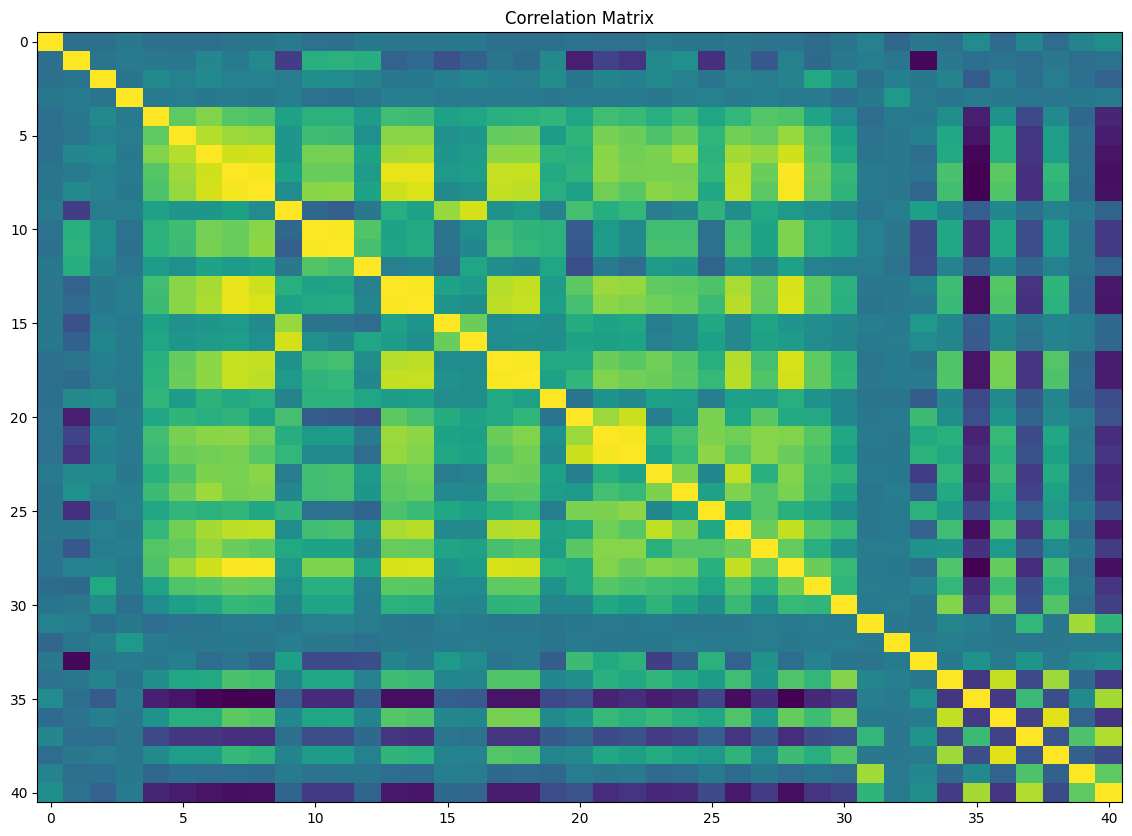

In [ ]:
plt.figure(figsize=(14,10))
corr=x.corr()
plt.imshow(corr,aspect='auto')
plt.title("Correlation Matrix")
plt.show()

**Standardization**

In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [ ]:
x_scaled

array([[-0.58191469, -1.40108842, -0.49969396, ..., -0.16623906,
        -1.46817686,  0.19138945],
       [-1.32505241, -0.01428174,  1.36901545, ..., -0.16623906,
        -1.46817686, -0.66146791],
       [-0.66817174,  0.67912159, -1.20045999, ..., -0.16623906,
        -1.46817686, -0.85958209],
       ...,
       [ 0.33373715,  1.37252493, -0.03251661, ..., -0.16623906,
         0.83574403,  1.36799438],
       [ 0.8977256 , -1.40108842,  1.83619281, ..., -0.16623906,
         0.54775392, -0.13960618],
       [ 1.32237572,  1.37252493, -1.66763734, ..., -0.16623906,
         0.83574403,  1.09256735]])

In [ ]:
pd.DataFrame(x_scaled)

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,-0.581915,-1.401088,-0.499694,-0.978040,-1.335031,-0.904118,-1.408249,-1.129079,-1.148786,-0.436699,...,-1.278177,1.0,0.898580,-0.272852,1.674613,-0.288505,-1.476607,-0.166239,-1.468177,0.191389
1,-1.325052,-0.014282,1.369015,-0.397581,0.453360,-0.904118,-0.702068,-0.624704,-0.560576,-0.457830,...,-1.278177,-1.0,-1.112867,-0.268913,0.065584,-0.288505,-1.476607,-0.166239,-1.468177,-0.661468
2,-0.668172,0.679122,-1.200460,0.763336,1.077217,1.608585,0.942012,0.750863,0.790129,0.081021,...,-1.278177,-1.0,0.898580,-0.221535,-0.888925,-0.288505,-1.476607,-0.166239,-1.468177,-0.859582
3,0.625684,-0.707685,-0.266105,0.298969,-1.501393,-0.904118,-1.397215,-0.899817,-0.909145,-0.214819,...,-1.278177,1.0,0.898580,-0.272677,1.592798,-0.248527,0.523712,-0.166239,-1.468177,-0.001893
4,-1.643540,-0.707685,-0.032517,1.111611,0.286998,-0.031652,0.986148,-0.120330,0.092991,-0.563488,...,-1.278177,1.0,0.898580,-0.263085,0.201942,-0.008660,-0.591851,-0.166239,-1.468177,-0.791933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,-0.986659,-1.401088,-1.200460,1.111611,0.952446,-0.904118,-0.282772,-0.349591,-0.429863,0.281770,...,1.210998,1.0,0.898580,-0.236675,0.338301,-0.248527,0.523712,-0.166239,0.835744,0.271118
1404,0.240845,1.372525,-0.733283,-1.326315,0.370179,1.259599,1.581989,2.355691,2.358690,0.218376,...,1.210998,-1.0,-1.112867,0.938327,-1.488902,0.391118,-1.168866,-0.166239,0.835744,-0.944143
1405,0.333737,1.372525,-0.032517,-0.745856,-2.208431,-0.904118,-1.783409,-1.495896,-1.344856,-4.715816,...,1.210998,-1.0,-1.112867,-0.274369,1.429168,-0.288505,0.869922,-0.166239,0.835744,1.367994
1406,0.897726,-1.401088,1.836193,-0.745856,0.578131,-0.799422,-0.801374,-0.899817,-0.952716,-0.066899,...,1.210998,-1.0,0.898580,-0.224450,-0.316220,-0.208549,0.100568,-0.166239,0.547754,-0.139606


In order to find the relation between features and gain important information , we need to find the covariance matrix .

**Covariance matrix**: Imagine you have dataset with two features height and weight . The covariance matrix will tell you how height varies with height( variance) , how wieght varies with weight(variance) , how weight varies with height and how height with weight


**in short** : the covariance matrix hepls PCA to understand how your data's features ar erelated so taht it can reduce dimension while keeping the most important information

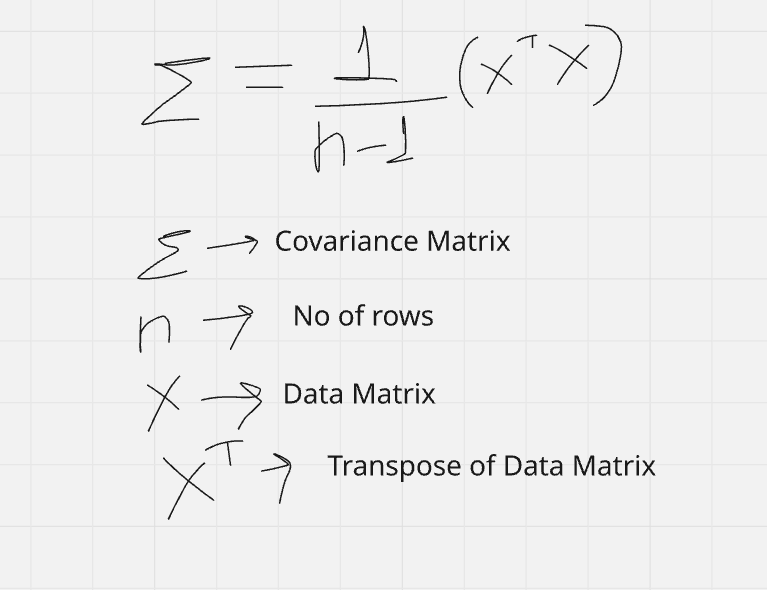

In [ ]:
x1=x_scaled.T
pd.DataFrame(x1)

,0,1,2,3,4,5,6,7,8,9,...,1398,1399,1400,1401,1402,1403,1404,1405,1406,1407
0,-0.581915,-1.325052,-0.668172,0.625684,-1.643540,-0.362954,-0.243522,-1.630270,1.368822,-1.278606,...,-0.243522,-1.039741,0.473075,-0.601820,1.634228,-0.986659,0.240845,0.333737,0.897726,1.322376
1,-1.401088,-0.014282,0.679122,-0.707685,-0.707685,-1.401088,-1.401088,0.679122,-1.401088,1.372525,...,-1.401088,-0.707685,-0.707685,-0.014282,0.679122,-1.401088,1.372525,1.372525,-1.401088,1.372525
2,-0.499694,1.369015,-1.200460,-0.266105,-0.032517,0.901838,1.369015,1.836193,-0.499694,-0.266105,...,-0.499694,1.135427,-0.966871,-0.266105,-0.499694,-1.200460,-0.733283,-0.032517,1.836193,-1.667637
3,-0.978040,-0.397581,0.763336,0.298969,1.111611,-1.558499,-0.397581,-0.281489,0.995520,1.575978,...,-1.210223,-0.281489,0.066786,1.227703,-0.049306,1.111611,-1.326315,-0.745856,-0.745856,0.879428
4,-1.335031,0.453360,1.077217,-1.501393,0.286998,0.578131,0.494950,-1.002307,-0.295269,-0.503221,...,0.162226,-0.128907,-2.166840,0.702903,-1.626164,0.952446,0.370179,-2.208431,0.578131,-2.000478
5,-0.904118,-0.904118,1.608585,-0.904118,-0.031652,1.468991,-0.869220,-0.904118,-0.904118,-0.904118,...,-0.799422,0.247538,-0.904118,-0.799422,-0.904118,-0.904118,1.259599,-0.904118,-0.799422,-0.834321
6,-1.408249,-0.702068,0.942012,-1.397215,0.986148,1.339239,-0.668965,-1.088261,-0.558624,-0.514488,...,-0.679999,0.324103,-1.507556,-0.569659,-0.944818,-0.282772,1.581989,-1.783409,-0.801374,-0.183465
7,-1.129079,-0.624704,0.750863,-0.899817,-0.120330,1.071828,0.154784,-1.037374,-0.166182,-0.395443,...,-0.303738,-0.487147,-1.266635,-0.487147,-1.037374,-0.349591,2.355691,-1.495896,-0.899817,-0.441295
8,-1.148786,-0.560576,0.790129,-0.909145,0.092991,1.007985,-0.015937,-0.974502,-0.320935,-0.277364,...,-0.451648,-0.386292,-1.127001,-0.473434,-0.822003,-0.429863,2.358690,-1.344856,-0.952716,-0.320935
9,-0.436699,-0.457830,0.081021,-0.214819,-0.563488,0.281770,0.556479,-0.753671,0.746662,-0.500093,...,0.767793,-0.299345,-2.074386,-0.119727,-1.609494,0.281770,0.218376,-4.715816,-0.066899,-0.362739


In [ ]:
cov_matrix=np.cov(x_scaled.T)
pd.DataFrame(cov_matrix)

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,1.000711,-0.050437,-0.053323,-0.001063,-0.062254,-0.052030,-0.058648,-0.025202,-0.022351,0.016560,...,6.297903e-02,-1.170844e-01,-0.000784,-0.046830,0.135436,-0.084617,0.104159,-7.049844e-02,0.075434,0.160529
1,-0.050437,1.000711,-0.027517,0.009594,0.001868,-0.014194,0.103879,0.016064,0.117014,-0.370120,...,3.018807e-02,-1.429190e-02,-0.634470,-0.003438,-0.060135,-0.031411,-0.064327,-1.047011e-02,-0.063987,-0.043677
2,-0.053323,-0.027517,1.000711,-0.020916,0.131057,0.060883,0.124199,0.063035,0.067771,0.038973,...,-5.316254e-02,5.345811e-02,0.001857,0.078420,-0.185939,0.052563,-0.068913,3.406890e-02,-0.059488,-0.144185
3,-0.001063,0.009594,-0.020916,1.000711,0.016055,0.030873,0.006338,0.021579,0.006927,0.045514,...,3.887966e-03,2.270679e-01,0.016621,-0.019845,0.027522,-0.000859,-0.013269,-1.520736e-02,0.003193,0.010015
4,-0.062254,0.001868,0.131057,0.016055,1.000711,0.584331,0.681442,0.551714,0.532201,0.285332,...,-7.596241e-02,1.010941e-02,0.008000,0.160918,-0.526700,0.181795,-0.301032,1.159455e-01,-0.115415,-0.492030
5,-0.052030,-0.014194,0.060883,0.030873,0.584331,1.000711,0.817423,0.757529,0.736396,0.209133,...,-3.326160e-02,7.689115e-04,0.052659,0.327896,-0.573764,0.383717,-0.401463,2.601252e-01,-0.057190,-0.538865
6,-0.058648,0.103879,0.124199,0.006338,0.681442,0.817423,1.000711,0.882967,0.891381,0.213334,...,-1.893354e-02,8.391243e-04,-0.066292,0.346046,-0.647689,0.386216,-0.404673,2.642954e-01,-0.070498,-0.582209
7,-0.025202,0.016064,0.063035,0.021579,0.551714,0.757529,0.882967,1.000711,0.979112,0.279352,...,1.258466e-02,3.226276e-03,-0.034042,0.519461,-0.669372,0.580993,-0.444487,4.412345e-01,-0.066552,-0.602102
8,-0.022351,0.117014,0.067771,0.006927,0.532201,0.736396,0.891381,0.979112,1.000711,0.138623,...,1.145076e-02,-7.339274e-03,-0.121366,0.493449,-0.663863,0.545278,-0.445637,4.092357e-01,-0.077214,-0.598714
9,0.016560,-0.370120,0.038973,0.045514,0.285332,0.209133,0.213334,0.279352,0.138623,1.000711,...,-1.176304e-02,4.395250e-02,0.272333,0.095833,-0.171446,0.112590,-0.055603,8.002441e-02,0.025814,-0.129031


**EigenVectors(The Direction)**

In PCA they represent the principal component axis along which we will project our data.
**EigenValues(The Importance)** : A large Eigen value means taht teh corresponding eigenvector(direction) captures the most important information

In [ ]:
eig_vals,eig_vecs=np.linalg.eig(cov_matrix)

In [ ]:
pd.DataFrame(eig_vals)

,0
0,15.768407
1,4.755909
2,2.670740
3,2.477890
4,1.967138
5,1.322228
6,1.270541
7,1.082818
8,0.992385
9,0.851933


In [ ]:
pd.DataFrame(eig_vecs)

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,-0.016517,-0.016124,-0.043249,-0.097651,0.049045,-0.330332,-0.235325,-0.321767,-0.687475,0.252543,...,-0.014291,-0.018547,0.002003,-0.002445,0.003980,0.001808,-0.000326,0.000330,0.000583,-0.000063
1,-0.011086,0.343403,-0.100926,-0.015239,-0.021316,-0.127699,0.089928,0.057628,0.158827,0.156991,...,0.078302,0.085171,0.049154,0.004208,-0.014155,-0.005615,0.000122,0.000759,-0.000061,0.000250
2,0.030989,0.036394,-0.028710,0.055151,-0.175062,0.590885,0.009901,-0.460575,-0.213663,-0.153096,...,-0.003064,0.008189,0.001959,0.010168,0.008252,-0.001261,-0.000063,0.000312,-0.000410,0.000035
3,0.003670,-0.027669,-0.019937,0.011959,0.029415,-0.099496,0.641043,0.072987,-0.349966,-0.072869,...,-0.010515,0.003338,0.000494,0.005594,0.008165,0.001551,0.000076,0.000682,-0.000028,-0.000231
4,0.153313,-0.013788,-0.241909,0.149426,-0.023835,0.108826,-0.015869,0.072048,0.026761,0.074221,...,0.057105,0.022263,-0.002346,0.013006,-0.015291,-0.001371,0.000817,-0.000407,0.000174,0.000247
5,0.199822,-0.014769,-0.100792,0.037782,0.126691,0.061716,0.001515,0.058636,0.000088,0.188944,...,0.054415,0.075696,-0.009621,0.038625,0.017131,-0.005406,0.001113,-0.000217,-0.000180,0.000973
6,0.226892,0.043142,-0.176449,0.023396,0.100098,0.049137,-0.005916,0.030025,-0.010391,0.079711,...,-0.488840,-0.523626,0.036579,-0.062620,-0.001572,0.043482,-0.001882,0.000750,0.001079,0.001085
7,0.241711,0.023192,-0.038850,-0.042633,0.035581,-0.083719,-0.000565,0.018042,-0.017597,-0.066288,...,0.080492,0.072315,-0.002883,-0.377226,0.117999,0.025642,-0.530378,-0.006325,0.013024,0.599266
8,0.235303,0.094369,-0.051902,-0.048078,0.077098,-0.060002,-0.012256,0.029630,-0.037979,-0.072727,...,0.018222,0.045031,-0.075388,0.476476,-0.060869,-0.029032,0.001046,0.023086,-0.754588,0.017231
9,0.077989,-0.283356,-0.172674,0.064232,-0.389868,-0.211085,0.045234,-0.126360,0.067195,-0.001617,...,-0.044652,0.060801,0.674887,0.158940,0.224789,0.078311,-0.002372,0.002310,-0.000942,-0.000238


#**Explained Variance**  :
Explained Variance tells us how much information (or Variance) each Principal Componnet captures. The more a variance, PC explains the most it is.

How we calculate the explained variance:
Each PC Component has a number called eigenvalue, which tell us how much information it holds.

TO find out how much of the total information this component explain or giving: We divide its eigenvalue by the sum of all the eigenvalues

In [ ]:
tot=sum(eig_vals)
tot

np.float64(41.02914001421463)

In [ ]:
exp_var=[(i/tot)*100 for i in sorted(eig_vals,reverse=True)]
exp_var

[np.float64(38.432214872580836),
 np.float64(11.591539359164448),
 np.float64(6.509373967071709),
 np.float64(6.039342621873424),
 np.float64(4.794489611193799),
 np.float64(3.222655517792794),
 np.float64(3.096678669769988),
 np.float64(2.639143575817729),
 np.float64(2.4187310552039087),
 np.float64(2.076409572987181),
 np.float64(1.91843259825725),
 np.float64(1.8688339867166084),
 np.float64(1.6525307825642517),
 np.float64(1.524986353813885),
 np.float64(1.3604475732554095),
 np.float64(1.1604629621330782),
 np.float64(1.1242535665321745),
 np.float64(1.0345925772206928),
 np.float64(0.8958683883629488),
 np.float64(0.8700102964336434),
 np.float64(0.7829911502672892),
 np.float64(0.7224358955481406),
 np.float64(0.6871609052629761),
 np.float64(0.6475384562558935),
 np.float64(0.6206088094735598),
 np.float64(0.5074707785347253),
 np.float64(0.4507355732389119),
 np.float64(0.41766950255780505),
 np.float64(0.28773490843967237),
 np.float64(0.19278535953562412),
 np.float64(0.130

Cumulative Explained Variance-

Inorder to find the proper PC and Explained variance that is why we need to find the cum sum.

Why it is important:

It helps to decide how many componets to keep.If the first few components explain 95% of the variance you can ignore the rest while keeping the most informtion.

In [ ]:
cum_var_explained=np.cumsum(exp_var)

In [ ]:
pd.DataFrame(cum_var_explained)

,0
0,38.432215
1,50.023754
2,56.533128
3,62.572471
4,67.366960
5,70.589616
6,73.686295
7,76.325438
8,78.744169
9,80.820579


In [ ]:
#Plot a graph between  individual explained variance and cumulative explained variance
#to check the percentage  of different pc like pc1,pc2,pc3...
#from the graph we will neglect the pc;s who dont impact our model and select the important one

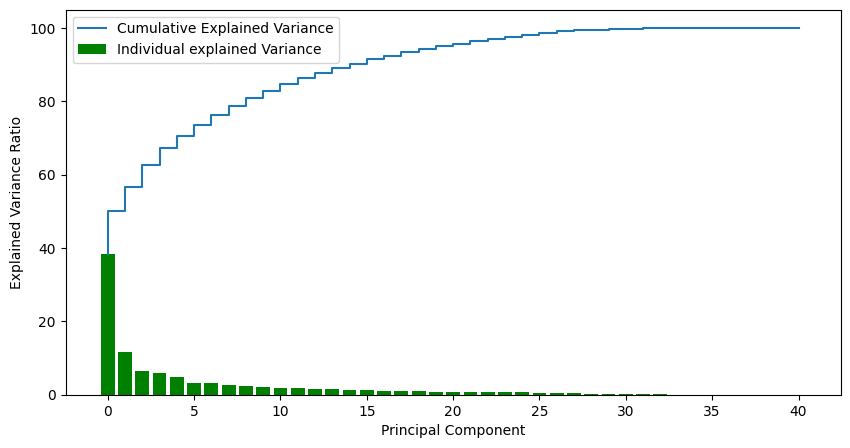

In [ ]:
#screeplot(comibantion of bar plot and step plot)
plt.figure(figsize=(10,5))
plt.bar(range(len(exp_var)),exp_var,label='Individual explained Variance',color='g')
plt.step(range(len(cum_var_explained)),cum_var_explained,label='Cumulative Explained Variance',)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.show()

In [ ]:
#from the graph we can choose ouur component between 20-30.

# **APPLY PCA**

In [ ]:
pca=PCA(0.90)
x_pca=pca.fit_transform(x_scaled)
print("Original Shape",x_scaled.shape)
print("Reduced Shape",x_pca.shape)

Original Shape (1408, 41)
Reduced Shape (1408, 16)


**Visualize PC1 and PC2**

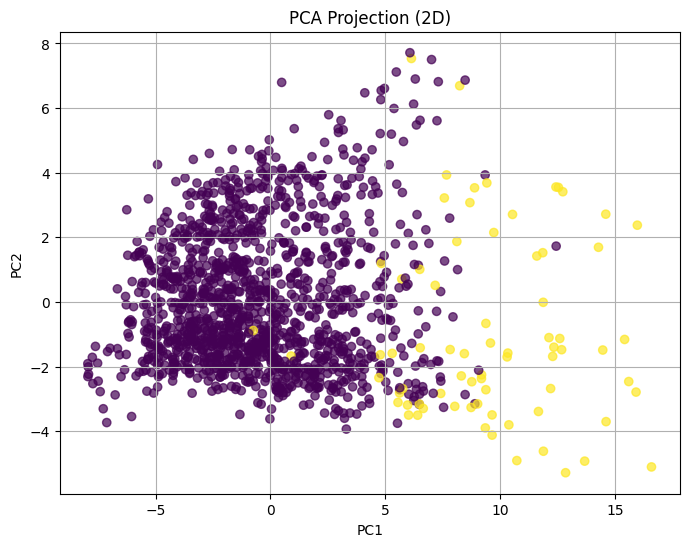

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0], x_pca[:,1], c=y, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (2D)")
plt.grid(True)
plt.show()

#**Machine Learning Process**

In [ ]:
#now use PCs for classification
x_train, x_test, y_train, y_test = train_test_split(
    x_pca, y, test_size=0.2, random_state=42, stratify=y
)
#we use stratify y beacuse our class is highly imbalanced


**Logistic Regression**

In [ ]:
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

**Predictions**


In [ ]:
y_pred=lr.predict(x_test)


In [ ]:
acc=accuracy_score(y_test,y_pred)
print("Accuracy",acc)

Accuracy 0.9822695035460993


#**Confusion matrix**

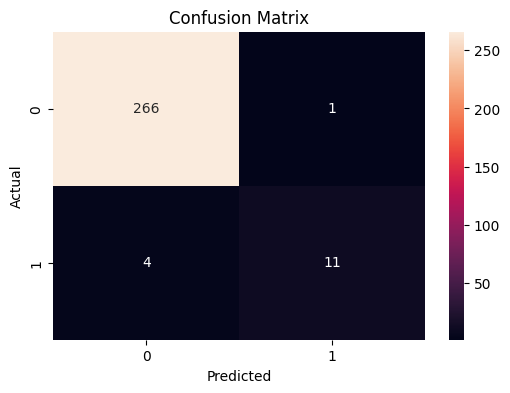

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Classification Report**

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       267
           1       0.92      0.73      0.81        15

    accuracy                           0.98       282
   macro avg       0.95      0.86      0.90       282
weighted avg       0.98      0.98      0.98       282



PCs=5 | Reduced from 41 → 5 | Reduction=87.80% | Accuracy=0.9894
PCs=7 | Reduced from 41 → 7 | Reduction=82.93% | Accuracy=0.9858
PCs=9 | Reduced from 41 → 9 | Reduction=78.05% | Accuracy=0.9787
PCs=11 | Reduced from 41 → 11 | Reduction=73.17% | Accuracy=0.9787
PCs=13 | Reduced from 41 → 13 | Reduction=68.29% | Accuracy=0.9858
PCs=15 | Reduced from 41 → 15 | Reduction=63.41% | Accuracy=0.9823
PCs=17 | Reduced from 41 → 17 | Reduction=58.54% | Accuracy=0.9752
PCs=19 | Reduced from 41 → 19 | Reduction=53.66% | Accuracy=0.9787
PCs=21 | Reduced from 41 → 21 | Reduction=48.78% | Accuracy=0.9752
PCs=23 | Reduced from 41 → 23 | Reduction=43.90% | Accuracy=0.9787
PCs=25 | Reduced from 41 → 25 | Reduction=39.02% | Accuracy=0.9787
PCs=27 | Reduced from 41 → 27 | Reduction=34.15% | Accuracy=0.9787
PCs=29 | Reduced from 41 → 29 | Reduction=29.27% | Accuracy=0.9823


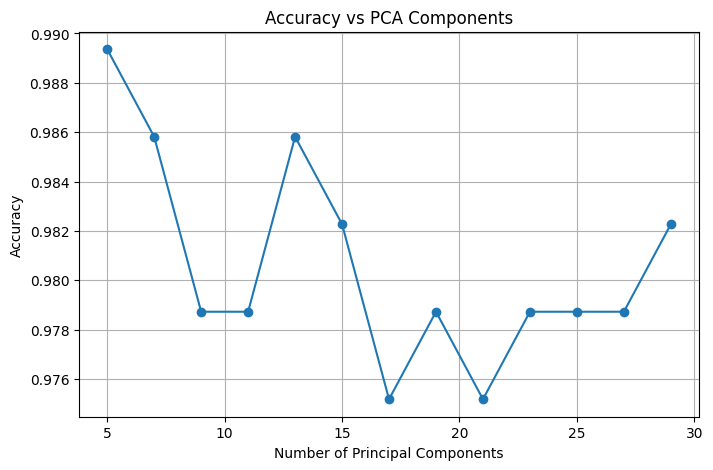

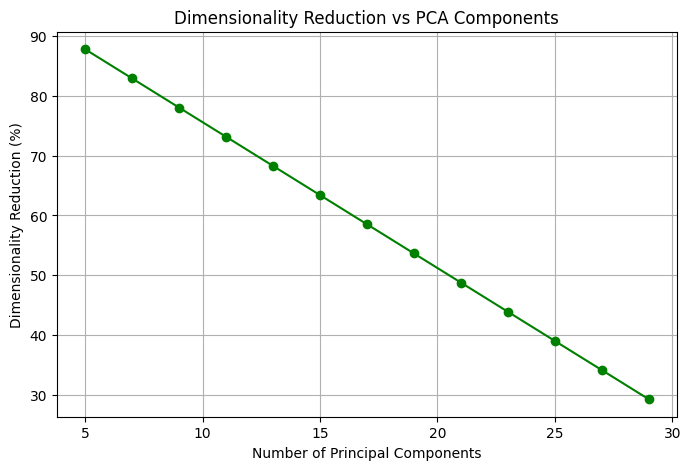

In [ ]:
# ===============================
# PCA Dimensionality + Accuracy
# ===============================

original_dim = x_scaled.shape[1]

pc_range = list(range(5, 31, 2))
accuracy_list = []
dim_reduction_list = []

for n in pc_range:
    # Apply PCA
    pca = PCA(n_components=n)
    X_pca_n = pca.fit_transform(x_scaled)

    reduced_dim = X_pca_n.shape[1]

    # Store reduction %
    reduction_percent = ((original_dim - reduced_dim) / original_dim) * 100
    dim_reduction_list.append(reduction_percent)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_pca_n, y, test_size=0.2, random_state=42, stratify=y
    )

    # Model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)

    print(f"PCs={n} | Reduced from {original_dim} → {reduced_dim} | Reduction={reduction_percent:.2f}% | Accuracy={acc:.4f}")

# ===============================
# Plot Accuracy vs PCs
# ===============================
plt.figure(figsize=(8,5))
plt.plot(pc_range, accuracy_list, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Accuracy")
plt.title("Accuracy vs PCA Components")
plt.grid(True)
plt.show()

# ===============================
# Plot Dimensionality Reduction %
# ===============================
plt.figure(figsize=(8,5))
plt.plot(pc_range, dim_reduction_list, marker='o', color='green')
plt.xlabel("Number of Principal Components")
plt.ylabel("Dimensionality Reduction (%)")
plt.title("Dimensionality Reduction vs PCA Components")
plt.grid(True)
plt.show()

In [ ]:
# Get original feature columns
original_columns = x.columns.tolist()

# Create new player using mean values
new_player_df = pd.DataFrame([x.mean()], columns=original_columns)

# Update specific stats
new_player_df.loc[0, 'PTS'] = 25
new_player_df.loc[0, 'FG'] = 9
new_player_df.loc[0, 'FGA'] = 18
new_player_df.loc[0, 'TRB'] = 7
new_player_df.loc[0, 'AST'] = 5

# Step 1: Scale
new_scaled = scaler.transform(new_player_df)

# Step 2: PCA transform
new_pca = pca.transform(new_scaled)

# Step 3: Predict
prediction = model.predict(new_pca)[0]

# Step 4: Probability
prob = model.predict_proba(new_pca)[0]

# 🔹 PRINT SCIENTIFIC FORMAT (RAW OUTPUT)
print("Raw Prediction:", prediction)
print("Raw Probability:", prob)

# 🔹 CONVERT TO PERCENTAGE
prob_percent = prob * 100

# 🔹 CLEAN OUTPUT
print("\n========== PREDICTION RESULT ==========")
print("Prediction:", "Playoff (1)" if prediction == 1 else "Not Playoff (0)")
print(f"Confidence: {prob_percent[prediction]:.2f}%")
print(f"Not Playoff (0): {prob_percent[0]:.2f}%")
print(f"Playoff (1): {prob_percent[1]:.2f}%")

Raw Prediction: 0
Raw Probability: [9.99617054e-01 3.82946325e-04]

========== PREDICTION RESULT ==========
Prediction: Not Playoff (0)
Confidence: 99.96%
Not Playoff (0): 99.96%
Playoff (1): 0.04%


In [ ]:
# Get a real playoff player
idx = y[y == 1].index[0]

new_player_df = x.loc[[idx]].copy()

# Pipeline
new_scaled = scaler.transform(new_player_df)
new_pca = pca.transform(new_scaled)

prediction = model.predict(new_pca)[0]
prob = model.predict_proba(new_pca)[0]

print("\n========== PLAYOFF EXAMPLE ==========")
print("Prediction:", "Playoff (1)" if prediction == 1 else "Not Playoff (0)")
print(f"Playoff Confidence: {prob[1]*100:.2f}%")


========== PLAYOFF EXAMPLE ==========
Prediction: Playoff (1)
Playoff Confidence: 99.75%


In [ ]:
pls = PLSRegression(n_components=16)

In [ ]:
pls.fit(X_train, y_train)

PLSRegression(n_components=16)

In [ ]:
X_train_pls = pls.transform(X_train)
X_test_pls = pls.transform(X_test)

In [ ]:
model_pls = LogisticRegression()
model_pls.fit(X_train_pls, y_train)

LogisticRegression()

In [ ]:
y_pred_pls = model_pls.predict(X_test_pls)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy (PLS):", accuracy_score(y_test, y_pred_pls))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_pls))


Accuracy (PLS): 0.975177304964539
Confusion Matrix:
 [[265   2]
 [  5  10]]
